# Data Wrangling - Part 1: Selecting Rows and Handling Missing Values

## Why data wrangling matters

Data wrangling transforms raw observations into analysis-ready data. Environmental datasets often contain multiple sites, sampling dates, inconsistent values, and missing measurements that must be filtered or cleaned before analysis.

In this lesson you will:
- inspect the values in a dataset before filtering
- select rows using Boolean conditions
- combine multiple filtering criteria
- identify and handle missing values.

## Objectives
By the end of this lesson, you should be able to:

1. Describe the role of data wrangling in an environmental data analysis workflow
2. Select rows from a pandas DataFrame using Boolean masks and `.loc[]`
3. Select rows from a pandas DataFrame using `.query()`
4. Combine multiple filtering criteria using comparison, logical, and membership operators
5. Identify, quantify, and filter missing values
6. Apply these techniques to create a small analysis-ready subset of an environmental dataset


## Set up your session

We will use a lake monitoring dataset from the North Temperate Lakes Long-Term Ecological Research (NTL-LTER) program. It contains repeated measurements collected from multiple lakes over many years.

> 👉*Before continuing:* Familiarize yourself the NTL-LTER dataset and why long-term monitoring is valuable.

In [50]:
# Packages
from pathlib import Path
import pandas as pd

In [51]:
# Paths
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / "data" / "raw"
processed_fldr = root_fldr / "data" / "processed"

raw_fldr

WindowsPath('c:/Users/qt29/Documents/ENV700/ENV700/data/raw')

In [52]:
# Data import
NTL_phys_data = pd.read_csv(
    raw_fldr / "NTL-LTER_Lake_ChemistryPhysics_Raw.csv",
    dtype={
        "lakeid": "category",
        "lakename": "category",
    },
    parse_dates=["sampledate"],
    date_format="%m/%d/%y"
)

In [53]:
# Preview the first few rows
NTL_phys_data.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN
1,L,Paul Lake,1984,148,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN
2,L,Paul Lake,1984,148,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN
3,L,Paul Lake,1984,148,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN
4,L,Paul Lake,1984,148,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN


In [54]:
# Show dataframe structure, data types, and non-null counts
NTL_phys_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38614 entries, 0 to 38613
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   lakeid           38614 non-null  category      
 1   lakename         38614 non-null  category      
 2   year4            38614 non-null  int64         
 3   daynum           38614 non-null  int64         
 4   sampledate       38614 non-null  datetime64[us]
 5   depth            38614 non-null  float64       
 6   temperature_C    34756 non-null  float64       
 7   dissolvedOxygen  34575 non-null  float64       
 8   irradianceWater  24327 non-null  float64       
 9   irradianceDeck   23195 non-null  float64       
 10  comments         368 non-null    str           
dtypes: category(2), datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 2.7 MB


In [55]:
# Quick summary statistics for numeric columns
NTL_phys_data.describe()

,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck
count,38614.000000,38614.00000,38614,38614.000000,34756.000000,34575.000000,24327.000000,23195.000000
mean,1998.567152,194.26941,1999-02-05 06:57:09.015383,4.390269,11.808707,4.970496,210.241580,720.508137
min,1984.000000,55.00000,1984-05-27 00:00:00,0.000000,0.300000,0.000000,-0.337000,1.500000
25%,1991.000000,166.00000,1991-08-08 00:00:00,1.500000,5.300000,0.300000,14.000000,353.000000
50%,1997.000000,194.00000,1997-07-28 00:00:00,4.000000,9.300000,5.600000,65.000000,747.000000
75%,2006.000000,222.00000,2006-06-06 00:00:00,6.500000,18.700000,8.400000,265.000000,1042.000000
max,2016.000000,307.00000,2016-08-17 00:00:00,20.000000,34.100000,802.000000,24108.000000,8532.000000
std,9.065429,33.52642,NaN,3.413634,6.939101,8.724565,345.452012,409.229792


---
## Inspect values before filtering

Before filtering a dataset, it is good practice to inspect the values you might filter on. This helps prevent mistakes caused by spelling, capitalization, abbreviations, or unexpected categories.


In [56]:
# What lakes are represented in the dataset?
NTL_phys_data["lakename"].unique()

['Paul Lake', 'Peter Lake', 'Tuesday Lake', 'East Long Lake', 'West Long Lake', 'Central Long Lake', 'Hummingbird Lake', 'Crampton Lake', 'Ward Lake']
Categories (9, str): ['Central Long Lake', 'Crampton Lake', 'East Long Lake', 'Hummingbird Lake', ..., 'Peter Lake', 'Tuesday Lake', 'Ward Lake', 'West Long Lake']

In [57]:
# 🔥Since `lakename` is a category field, we can use its `cat.categories` property to list unique values  
NTL_phys_data['lakename'].cat.categories

Index(['Central Long Lake', 'Crampton Lake', 'East Long Lake',
       'Hummingbird Lake', 'Paul Lake', 'Peter Lake', 'Tuesday Lake',
       'Ward Lake', 'West Long Lake'],
      dtype='str')

In [58]:
# How many observations are available for each lake?
NTL_phys_data["lakename"].value_counts()

lakename
Peter Lake           11288
Paul Lake            10325
Tuesday Lake          6107
West Long Lake        4188
East Long Lake        3905
Crampton Lake         1234
Ward Lake              598
Central Long Lake      539
Hummingbird Lake       430
Name: count, dtype: int64

👉 *How might you display this graphically?*

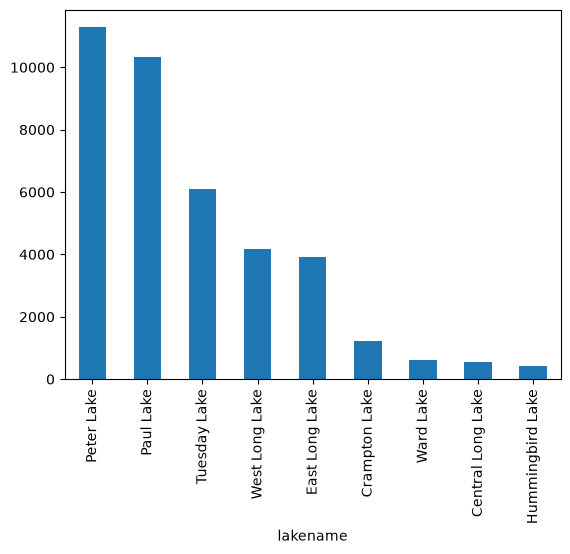

In [59]:
# Plot how many observations are available for each lake
NTL_phys_data["lakename"].value_counts().plot(kind='bar');

In [60]:
# What is the distribution of temperature values?
NTL_phys_data["temperature_C"].describe()

count    34756.000000
mean        11.808707
std          6.939101
min          0.300000
25%          5.300000
50%          9.300000
75%         18.700000
max         34.100000
Name: temperature_C, dtype: float64

👉 *How might you display this graphically?*

<Axes: ylabel='Frequency'>

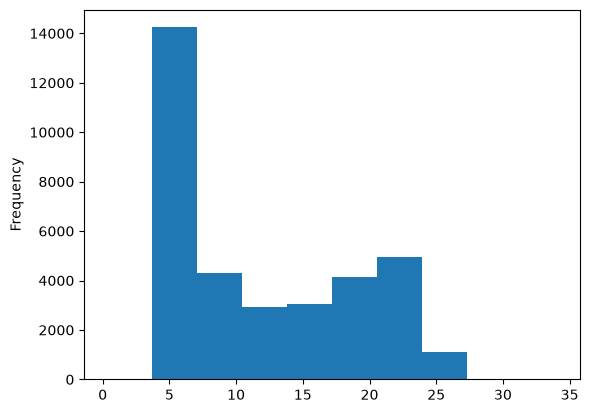

In [61]:
# Plot the distribution of depth values
NTL_phys_data['temperature_C'].plot(kind='hist')

---
## ◾Subsetting data: rows

Suppose we only want to work with specific observations in the northern temperate lakes dataset. For example, we may only want data collected at the surface, from a specific lake, or from a selected set of lakes.

There are two common ways to select rows in pandas:

- `.loc[]` with a **Boolean mask**
- `.query()` with a **query string**


### Selecting rows using `.loc[]` and Boolean masks

A **Boolean mask** is a Series of `True` and `False` values. Each value indicates whether the corresponding row meets a condition.

When a Boolean mask is passed to `.loc[]`, pandas returns only the rows where the mask is `True`.


In [62]:
# Create a Boolean mask for surface records where depth equals 0
surface_mask = NTL_phys_data["depth"] == 0

In [63]:
# Inspect the mask itself
surface_mask.head(10)

0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: depth, dtype: bool

In [64]:
# Count how many rows meet the condition
surface_mask.sum()

np.int64(1902)

In [65]:
# Apply the mask to create a dataframe of surface records
NTL_surface_loc = NTL_phys_data.loc[surface_mask]
NTL_surface_loc.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.0,14.5,9.5,1750.0,1620.0,NaN
17,R,Peter Lake,1984,149,1984-05-28,0.0,14.8,9.2,1630.0,1540.0,NaN
39,T,Tuesday Lake,1984,150,1984-05-29,0.0,15.0,9.5,1850.0,1960.0,NaN
55,L,Paul Lake,1984,155,1984-06-03,0.0,18.8,8.0,1100.0,1050.0,NaN
71,R,Peter Lake,1984,156,1984-06-04,0.0,18.8,9.0,275.0,275.0,NaN


Notice that the index values in the filtered dataframe are not necessarily sequential. The original row labels were preserved when the rows were filtered.

If you want a fresh sequential index, use `.reset_index(drop=True)`.


In [66]:
# Reset the index after filtering
NTL_surface_loc_reset = NTL_surface_loc.reset_index(drop=True)
NTL_surface_loc_reset.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.0,14.5,9.5,1750.0,1620.0,NaN
1,R,Peter Lake,1984,149,1984-05-28,0.0,14.8,9.2,1630.0,1540.0,NaN
2,T,Tuesday Lake,1984,150,1984-05-29,0.0,15.0,9.5,1850.0,1960.0,NaN
3,L,Paul Lake,1984,155,1984-06-03,0.0,18.8,8.0,1100.0,1050.0,NaN
4,R,Peter Lake,1984,156,1984-06-04,0.0,18.8,9.0,275.0,275.0,NaN


### Selecting rows using `.query()`

A **query string** is a text expression that describes the filtering condition. The expression is passed to `.query()`.

Many people find `.query()` readable, especially when combining several conditions.


In [67]:
# Create a query string for surface records
surface_query = "depth == 0"

In [68]:
# Apply the query string
NTL_surface_query = NTL_phys_data.query(surface_query)
NTL_surface_query.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.0,14.5,9.5,1750.0,1620.0,NaN
17,R,Peter Lake,1984,149,1984-05-28,0.0,14.8,9.2,1630.0,1540.0,NaN
39,T,Tuesday Lake,1984,150,1984-05-29,0.0,15.0,9.5,1850.0,1960.0,NaN
55,L,Paul Lake,1984,155,1984-06-03,0.0,18.8,8.0,1100.0,1050.0,NaN
71,R,Peter Lake,1984,156,1984-06-04,0.0,18.8,9.0,275.0,275.0,NaN


In [69]:
# Confirm that both approaches return the same number of rows
NTL_surface_loc.shape, NTL_surface_query.shape

((1902, 11), (1902, 11))

### `.loc[]` or `.query()`?

| Method | Often useful when... |
| --- | --- |
| `.loc[]` | You want explicit pandas syntax or need maximum flexibility |
| `.query()` | You want a readable expression for row filtering |
| `.loc[]` | You are building filters programmatically from existing Python objects |
| `.query()` | Your expression is close to natural language or SQL-like syntax |

Both are useful. In this course, you should be able to read and use both patterns.


---
## ◾Element-wise comparison operators

Boolean masks and query strings can use comparison operators to select records.

| Operator | Meaning |
| :---: | :--- |
| `==` | equals |
| `!=` | does not equal |
| `<` | is less than |
| `<=` | is less than or equal to |
| `>` | is greater than |
| `>=` | is greater than or equal to |


Comparison operators can be used on categorical or text variables as well as numeric variables.


In [70]:
# Select records from Peter Lake
NTL_peter_lake = NTL_phys_data.loc[NTL_phys_data["lakename"] == "Peter Lake"]
NTL_peter_lake.shape

(11288, 11)

In [71]:
# The same selection using query
NTL_peter_lake_query = NTL_phys_data.query('lakename == "Peter Lake"')
NTL_peter_lake_query.shape


(11288, 11)

In [72]:
# The same selection using query
NTL_peter_lake_query = NTL_phys_data.query('lakename == "Peter Lake"')
NTL_peter_lake_query.shape

(11288, 11)

---
### 👉 Exercise 1: Filter by lake name

Use either `.loc[]` or `.query()` to answer the following questions.

1. How many records are there for Paul Lake? (answer = `10,325`)
2. How many records are for lakes other than Paul Lake? (answer = `28,289`)
3. Why might the number of observations differ among lakes?


In [73]:
# 1. Find the number of records for Paul Lake

NTL_paul_lake = NTL_phys_data.loc[NTL_phys_data["lakename"] == "Paul Lake"]
NTL_paul_lake.shape

(10325, 11)

In [74]:
# 2. Find the number of records that are not from Paul Lake
NTL_not_paul_lake = NTL_phys_data.loc[NTL_phys_data["lakename"] != "Paul Lake"]
NTL_not_paul_lake.shape

(28289, 11)

**Discussion:** Briefly interpret the results before continuing.

---
## ◾Logical operators for combining conditions

Logical operators allow us to combine multiple Boolean conditions.

| Operator | Meaning |
| :---: | :--- |
| `&` | and |
| `\|` | or |
| `~` | not |

When combining Boolean expressions in pandas, put each comparison inside parentheses.

Correct:

```python
(df["depth"] == 0) & (df["lakename"] == "Peter Lake")
```

Incorrect:

```python
df["depth"] == 0 & df["lakename"] == "Peter Lake"
```


In [75]:
# Find records that are either Peter Lake or Paul Lake using a Boolean mask
peter_or_paul_mask = (
    (NTL_phys_data["lakename"] == "Peter Lake") |
    (NTL_phys_data["lakename"] == "Paul Lake")
)

peter_or_paul_mask.sum()

np.int64(21613)

In [76]:
# Apply the mask
NTL_peter_or_paul = NTL_phys_data.loc[peter_or_paul_mask]
NTL_peter_or_paul.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN
1,L,Paul Lake,1984,148,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN
2,L,Paul Lake,1984,148,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN
3,L,Paul Lake,1984,148,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN
4,L,Paul Lake,1984,148,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN


In [77]:
# Find surface records from Peter Lake
peter_surface = NTL_phys_data.loc[
    (NTL_phys_data["lakename"] == "Peter Lake") &
    (NTL_phys_data["depth"] == 0)
]

peter_surface.shape

(530, 11)

---
### Exercise 2: Combine conditions

Use Boolean masks to answer the following questions.

1. How many records are both from Peter Lake and Paul Lake?
2. Does that answer make sense? Why or why not?
3. How many surface records (depth is zero) are available for Paul Lake?


In [78]:
# 1. Find records that are both Peter Lake and Paul Lake
peter_and_paul_mask = (
    (NTL_phys_data["lakename"] == "Peter Lake") &
    (NTL_phys_data["lakename"] == "Paul Lake")
)

peter_and_paul_mask.sum()



np.int64(0)

SO I think the reason why it is 0 because it treat it as two conditions. So like typically we would think it should be the sume of both lakes but in this case, it assume that each observation should paul and peter lake in it. 

**Discussion:** Briefly interpret the results before continuing.

In [79]:
# 3. Find surface records for Paul Lake
paul_surface = NTL_phys_data.loc[
    (NTL_phys_data["lakename"] == "Paul Lake") &
    (NTL_phys_data["depth"] == 0)
]

paul_surface.shape

(524, 11)

### Combining conditions with `.query()`

The `.query()` method can also combine conditions. Inside a query string, use `and`, `or`, and `not` rather than `&`, `|`, and `~`.


In [80]:
# Find records that are either Peter Lake or Paul Lake using query
NTL_peter_or_paul_query = NTL_phys_data.query(
    'lakename == "Peter Lake" or lakename == "Paul Lake"'
)

NTL_peter_or_paul_query.shape

(21613, 11)

In [81]:
# Find surface records from Peter Lake using query
NTL_peter_surface_query = NTL_phys_data.query(
    'lakename == "Peter Lake" and depth == 0'
)

NTL_peter_surface_query.shape

(530, 11)

---
## ◾Membership comparisons with `.isin()`

The `.isin()` method creates a Boolean mask by checking whether values are members of a list or other collection.

This is useful when you want to select observations from several categories.


In [82]:
# Select records from Peter Lake, Paul Lake, and Tuesday Lake
selected_lakes = ["Peter Lake", "Paul Lake", "Tuesday Lake"]

NTL_three_lakes = NTL_phys_data.loc[NTL_phys_data["lakename"].isin(selected_lakes)]
NTL_three_lakes.shape

(27720, 11)

In [83]:
# Check which lakes are present in the filtered dataset
NTL_three_lakes["lakename"].value_counts()

lakename
Peter Lake           11288
Paul Lake            10325
Tuesday Lake          6107
Central Long Lake        0
Crampton Lake            0
East Long Lake           0
Hummingbird Lake         0
Ward Lake                0
West Long Lake           0
Name: count, dtype: int64

---
### Exercise 3: Use `.isin()`

Create a dataframe containing only observations from Peter Lake, Paul Lake, and Tuesday Lake where depth is greater than 5 meters.

Then answer:

1. How many rows are in the resulting dataframe?
2. Which lake contributes the most observations?


In [84]:
# Create a filtered dataframe using .isin() and a year condition
selected_lakes = ["Peter Lake", "Paul Lake", "Tuesday Lake"]

NTL_deeper_three_lakes = NTL_phys_data.loc[
    (NTL_phys_data["lakename"].isin(selected_lakes)) & 
    (NTL_phys_data["depth"] > 5)]
NTL_deeper_three_lakes.shape



(10289, 11)

In [85]:
# Count observations by lake in your filtered dataframe
NTL_deeper_three_lakes["lakename"].value_counts()

lakename
Peter Lake           4515
Paul Lake            3602
Tuesday Lake         2172
Central Long Lake       0
Crampton Lake           0
East Long Lake          0
Hummingbird Lake        0
Ward Lake               0
West Long Lake          0
Name: count, dtype: int64

---
## ◾Working with missing values

Missing values are common in environmental datasets. Instruments fail, samples are not collected, sensors are below detection limits, and historical datasets may combine many protocols or sampling campaigns.

In pandas, missing values are often represented as `NaN`.

Two common methods are:

- `.isna()` returns `True` for missing values
- `.notna()` returns `True` for non-missing values


In [86]:
# Count missing values in each column
NTL_phys_data.isna().sum()

lakeid                 0
lakename               0
year4                  0
daynum                 0
sampledate             0
depth                  0
temperature_C       3858
dissolvedOxygen     4039
irradianceWater    14287
irradianceDeck     15419
comments           38246
dtype: int64

In [87]:
# Calculate percent missing in each column
missing_percent = NTL_phys_data.isna().mean().sort_values(ascending=False) * 100
missing_percent

comments           99.046978
irradianceDeck     39.931113
irradianceWater    36.999534
dissolvedOxygen    10.459937
temperature_C       9.991195
lakeid              0.000000
lakename            0.000000
year4               0.000000
depth               0.000000
daynum              0.000000
sampledate          0.000000
dtype: float64

In [88]:
# Select rows where dissolved oxygen is missing
NTL_missing_DO = NTL_phys_data.loc[NTL_phys_data["dissolvedOxygen"].isna()]
NTL_missing_DO.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
1,L,Paul Lake,1984,148,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN
2,L,Paul Lake,1984,148,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN
3,L,Paul Lake,1984,148,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN
5,L,Paul Lake,1984,148,1984-05-27,1.50,NaN,NaN,610.0,1620.0,NaN
18,R,Peter Lake,1984,149,1984-05-28,0.25,NaN,NaN,1530.0,1540.0,NaN


In [89]:
# Select rows where dissolved oxygen is not missing
NTL_complete_DO = NTL_phys_data.loc[NTL_phys_data["dissolvedOxygen"].notna()]
NTL_complete_DO.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.0,14.5,9.5,1750.0,1620.0,NaN
4,L,Paul Lake,1984,148,1984-05-27,1.0,14.5,8.8,870.0,1620.0,NaN
6,L,Paul Lake,1984,148,1984-05-27,2.0,14.2,8.6,420.0,1620.0,NaN
7,L,Paul Lake,1984,148,1984-05-27,3.0,11.0,11.5,220.0,1620.0,NaN
8,L,Paul Lake,1984,148,1984-05-27,4.0,7.0,11.9,100.0,1620.0,NaN


In [90]:
# Compare row counts
NTL_phys_data.shape[0], NTL_missing_DO.shape[0], NTL_complete_DO.shape[0]

(38614, 4039, 34575)

---
### Exercise 4: Missing values

Answer the following questions.

1. Which column has the most missing values?
2. What percentage of `dissolvedOxygen` values are missing?
3. Create a dataframe containing only rows where `temperature`, `dissolvedOxygen`, and `depth` are all non-missing.


In [91]:
# 1. Which column has the most missing values?
NTL_phys_data.isna().sum()

lakeid                 0
lakename               0
year4                  0
daynum                 0
sampledate             0
depth                  0
temperature_C       3858
dissolvedOxygen     4039
irradianceWater    14287
irradianceDeck     15419
comments           38246
dtype: int64

In [101]:
# 2. What percentage of dissolvedOxygen values are missing?
missing_percent_DO = NTL_phys_data["dissolvedOxygen"].isna().mean() * 100
print(missing_percent_DO)

10.459936810483244


In [93]:
# 3. Keep rows where temperature, dissolvedOxygen, and depth are all non-missing
NTL_complete_data = NTL_phys_data.loc[
    NTL_phys_data["temperature_C"].notna() & 
    NTL_phys_data["dissolvedOxygen"].notna() & 
    NTL_phys_data["depth"].notna()
]
NTL_complete_data.head()

NTL_phys_data.shape[0], NTL_complete_data.shape[0]

(38614, 34546)

---
## A note on method chaining

As your pandas workflows become more complex, you may see code written as a **method chain**. Method chaining applies several steps in sequence while keeping the code readable.

For example, this chain filters the data to surface observations from three selected lakes and then resets the index.


In [94]:
selected_lakes = ["Peter Lake", "Paul Lake", "Tuesday Lake"]

NTL_three_lakes_surface = (
    NTL_phys_data
    .loc[lambda df: df["lakename"].isin(selected_lakes)]
    .loc[lambda df: df["depth"] == 0]
    .reset_index(drop=True)
)

NTL_three_lakes_surface.head()

,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.0,14.5,9.5,1750.0,1620.0,NaN
1,R,Peter Lake,1984,149,1984-05-28,0.0,14.8,9.2,1630.0,1540.0,NaN
2,T,Tuesday Lake,1984,150,1984-05-29,0.0,15.0,9.5,1850.0,1960.0,NaN
3,L,Paul Lake,1984,155,1984-06-03,0.0,18.8,8.0,1100.0,1050.0,NaN
4,R,Peter Lake,1984,156,1984-06-04,0.0,18.8,9.0,275.0,275.0,NaN


Method chaining is not required, but it is a useful pattern for building readable and reproducible data workflows.


---
## Capstone exercise: Create an analysis-ready subset

Create a new dataframe named `NTL_analysis_subset` that contains:

- Surface observations only (`depth == 0`)
- Peter Lake, Paul Lake, and Tuesday Lake only
- Non-missing `temperature` values
- Non-missing `dissolvedOxygen` values

Then answer:

1. How many rows are in the final subset?
2. How many observations are available for each lake?
3. What years are represented in the final subset?
4. Why might this subset be useful for exploratory analysis?


In [95]:
# Create NTL_analysis_subset here

NTL_analysis_subset = NTL_phys_data.loc[
    NTL_phys_data["lakename"].isin(["Peter Lake", "Paul Lake", "Tuesday Lake"]) & 
    (NTL_phys_data["depth"] == 0) & 
    NTL_phys_data["temperature_C"].notna() & 
    NTL_phys_data["dissolvedOxygen"].notna()
]

In [96]:
# 1. Number of rows in the final subset
len(NTL_analysis_subset)

1352

In [97]:
# 2. Number of observations by lake
NTL_analysis_subset["lakename"].value_counts()

lakename
Peter Lake           524
Paul Lake            522
Tuesday Lake         306
Central Long Lake      0
Crampton Lake          0
East Long Lake         0
Hummingbird Lake       0
Ward Lake              0
West Long Lake         0
Name: count, dtype: int64

In [98]:
# 3. Years represented in the final subset
NTL_analysis_subset["sampledate"].dt.year.unique()

array([1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016],
      dtype=int32)

**Discussion:** Briefly interpret the results before continuing.

---
## Key takeaways

- Data wrangling prepares raw data for exploration, visualization, and analysis.
- Boolean masks are `True`/`False` filters that can be used with `.loc[]`.
- `.query()` provides a readable alternative for row filtering.
- Use comparison operators such as `==`, `!=`, `<`, and `>=` to define conditions.
- Use logical operators to combine conditions: `&`, `|`, and `~` with Boolean masks; `and`, `or`, and `not` inside `.query()`.
- Use `.isin()` to filter by membership in a list of values.
- Use `.isna()` and `.notna()` to identify and filter missing values.


---
## Preview: next wrangling topics

In later wrangling lessons, we will extend these ideas to:

- Selecting columns
- Renaming variables
- Creating new variables
- Sorting records
- Grouped summaries
- Joining datasets
- Reshaping data between wide and long formats
